# **Pemodelan Berbasis Metrik Jarak dan K-Nearest Neighbors**

Catatan ini menguraikan arsitektur pemodelan machine learning yang berlandaskan pada kalkulasi metrik jarak, dengan fokus utama pada algoritma K-Nearest Neighbors (KNN). Pembahasan mencakup landasan matematis kedekatan data, mekanisme klasifikasi KNN, signifikansi penskalaan fitur (feature scaling), teknik optimasi hiperparameter, serta evaluasi performa model menggunakan metrik klasifikasi komprehensif.
### **Tujuan Pembelajaran **
- Konseptualisasi Jarak: Memahami bagaimana jarak matematis direpresentasikan dalam ruang fitur machine learning.

- Metrik Kalkulasi: Mampu menghitung dan membedakan Euclidean, Manhattan, dan Minkowski distance.Mekanisme Algoritma: Mengimplementasikan pengklasifikasi KNN dan memahami prinsip kerja lazy learning.

- Dampak Parameter: Menganalisis pengaruh nilai $k$ dan urgensi penskalaan fitur terhadap batas keputusan model.

- Optimasi Sistematis: Menggunakan GridSearchCV dan RandomizedSearchCV untuk menemukan kombinasi hiperparameter optimal.

- Evaluasi Multidimensi: Mengevaluasi model melampaui metrik akurasi menggunakan Confusion Matrix, Precision, Recall, F1-Score, dan Learning Curve.

## **Bagian 1: Persiapan Lingkungan Kerja (Environment Setup)**

Modul ini beroperasi menggunakan pustaka analitik standar Python. Dataset yang diutilisasi mencakup dataset bawaan Iris serta dataset sintetik yang secara khusus dibuat untuk mendemonstrasikan sensitivitas metrik jarak.

In [12]:
# Memuat pustaka manipulasi data dan visualisasi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Memuat dataset
from sklearn.datasets import load_iris, make_circles, make_classification

# Memuat modul pemodelan dan optimasi
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, learning_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Memuat metrik evaluasi
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)

# Konfigurasi parameter dasar
np.random.seed(2024)
pd.set_option("display.max_columns", 100)

## **Bagian 2: Landasan Metrik Jarak (Distance Metrics)**

Metrik jarak adalah instrumen matematis untuk mengukur tingkat kedekatan atau disparitas antara dua titik data dalam ruang multidimensi. Dalam paradigma KNN, definisi "tetangga" secara absolut ditentukan oleh rumusan jarak yang dipilih.1. Jarak Euclidean (Euclidean Distance)Merupakan metrik jarak garis lurus terpendek antara dua titik. Sangat ideal untuk data numerik kontinu yang telah diselaraskan skalanya. Untuk titik $x$ dan $y$ dengan $n$ fitur, formulasinya adalah:$$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$2. Jarak Manhattan (Manhattan / City Block Distance)Menghitung jarak berdasarkan total selisih absolut antar-koordinat (seolah menyusuri blok jalanan kota). Metrik ini sangat tangguh terhadap presensi data pencilan (outlier).$$d(x, y) = \sum_{i=1}^{n} |x_i - y_i|$$3. Jarak Minkowski (Minkowski Distance)Merupakan bentuk generalisasi matematis dari metrik Euclidean dan Manhattan, yang dikendalikan oleh parameter derajat $p$:$$d(x, y) = \left( \sum_{i=1}^{n} |x_i - y_i|^p \right)^{\frac{1}{p}}$$Kaidah: Jika $p=1$, formula ekuivalen dengan Manhattan. Jika $p=2$, ekuivalen dengan Euclidean.

In [13]:
from scipy.spatial.distance import euclidean, cityblock, minkowski

# Simulasi Koordinat Titik
x = np.array([2, 3])
y = np.array([6, 8])

# Komparasi Hasil Kalkulasi
pd.DataFrame({
    "Metrik Jarak": ["Euclidean (Garis Lurus)", "Manhattan (Blok)", "Minkowski (p=3)"],
    "Nilai Kalkulasi": [euclidean(x, y), cityblock(x, y), minkowski(x, y, p=3)]
})

,Metrik Jarak,Nilai Kalkulasi
0,Euclidean (Garis Lurus),6.403124
1,Manhattan (Blok),9.000000
2,Minkowski (p=3),5.738794


## **Bagian 3: Membedah K-Nearest Neighbors (KNN)**

KNN merupakan algoritma supervised berkarakteristik lazy learning, di mana model tidak mengabstraksi fungsi pemetaan matematika secara eksplisit selama fase pelatihan. Prediksi sepenuhnya dilakukan saat inferensi
dengan cara:

1. Menghitung jarak data baru terhadap seluruh data latih.

2. Mengisolasi $k$ jumlah sampel latih dengan jarak terpendek.

3. Menetapkan prediksi berdasarkan skema voting mayoritas.

Formulasi Klasifikasi (Voting):$$\hat{y} = \text{argmax}_{c} \sum_{x_i \in N_k(x)} I(y_i = c)$$

(Di mana $N_k(x)$ adalah himpunan tetangga terdekat, dan $I$ adalah fungsi indikator kesamaan kelas).

In [14]:
# 1. Persiapan Dataset Iris
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=2024, stratify=iris.target)

# 2. Implementasi KNN Dasar (k=3)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

print(f"Akurasi Baseline KNN (Tanpa Penskalaan): {accuracy_score(y_test, knn.predict(X_test)):.4f}")

Akurasi Baseline KNN (Tanpa Penskalaan): 0.9333


### **Urgensi Penskalaan Fitur (Feature Scaling)**
Karena KNN secara absolut mengandalkan perhitungan jarak spasial, fitur dengan rentang nilai masif (misal: gaji dalam jutaan) akan mendominasi fitur bernilai kecil (misal: umur), menganulir signifikansi fitur kecil tersebut. Oleh karena itu, standardisasi skala adalah sebuah kewajiban.

In [15]:
# Implementasi KNN Terintegrasi Penskalaan menggunakan Pipeline
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=3))
])

pipe_knn.fit(X_train, y_train)
print(f"Akurasi KNN (Dengan Penskalaan): {accuracy_score(y_test, pipe_knn.predict(X_test)):.4f}")

Akurasi KNN (Dengan Penskalaan): 0.9333


## **Bagian 4: Dinamika Nilai $k$ dan Evaluasi Metrik Berbeda**
Penentuan parameter $k$ mengendalikan kompleksitas batas keputusan model:$k$ terlalu kecil (misal $k=1$): Model sangat sensitif terhadap noise, memicu batas yang rumit dan menyebabkan Overfitting.$k$ terlalu besar: Model menelan rentang spasial yang terlalu luas, memicu batas yang terlalu datar dan menyebabkan Underfitting.

## **Bagian 5: Optimasi Hiperparameter (Hyperparameter Tuning)**
Untuk menemukan konfigurasi algoritma yang paling ekuilibrium, kita mengeksekusi pencarian parameter menggunakan fungsi komputasi otomatis yang terhubung dengan prosedur validasi silang.

Pendekatan GridSearchCV
Mengeksplorasi seluruh permutasi kombinasi secara komprehensif (exhaustive search).

In [16]:
# Definisi Ruang Pencarian Parameter KNN
param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11],
    "knn__weights": ["uniform", "distance"], # Bobot merata vs. Bobot jarak
    "knn__metric": ["euclidean", "manhattan", "minkowski"]
}

grid_search = GridSearchCV(pipe_knn, param_grid, cv=5, scoring="accuracy")
grid_search.fit(X_train, y_train)

print("Kombinasi Parameter Paling Optimal:", grid_search.best_params_)
print(f"Skor CV Maksimum: {grid_search.best_score_:.4f}")

Kombinasi Parameter Paling Optimal: {'knn__metric': 'euclidean', 'knn__n_neighbors': 5, 'knn__weights': 'distance'}
Skor CV Maksimum: 0.9750


## **Bagian 6: Penilaian Kinerja Multidimensi (Performance Evaluation)**
Skor akurasi global sering kali memanipulasi kenyataan, khususnya ketika berhadapan dengan data yang tidak seimbang (Imbalanced Dataset). Evaluasi harus dipecah ke dalam metrik-metrik konklusif berbasis Confusion Matrix.

In [17]:
# Ekstraksi Model Terbaik
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

# 1. Matriks Konfusi (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred_best)
display(pd.DataFrame(
    cm,
    index=[f"Aktual {name}" for name in iris.target_names],
    columns=[f"Prediksi {name}" for name in iris.target_names]
))

# 2. Laporan Klasifikasi Komprehensif
print("\nLaporan Klasifikasi Final:")
print(classification_report(y_test, y_pred_best, target_names=iris.target_names))

,Prediksi setosa,Prediksi versicolor,Prediksi virginica
Aktual setosa,10,0,0
Aktual versicolor,0,9,1
Aktual virginica,0,1,9



Laporan Klasifikasi Final:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



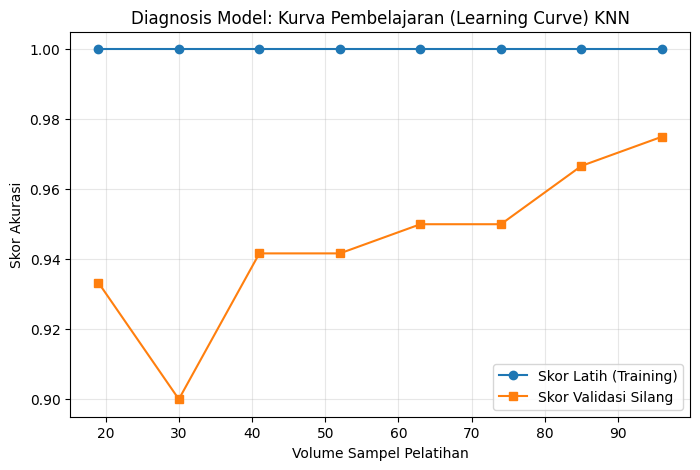

In [18]:
# 3. Analisis Kurva Pembelajaran (Learning Curve)
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train, train_sizes=np.linspace(0.2, 1.0, 8), cv=5
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), marker="o", label="Skor Latih (Training)")
plt.plot(train_sizes, np.mean(test_scores, axis=1), marker="s", label="Skor Validasi Silang")
plt.xlabel("Volume Sampel Pelatihan")
plt.ylabel("Skor Akurasi")
plt.title("Diagnosis Model: Kurva Pembelajaran (Learning Curve) KNN")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## **Kesimpulan Analitik**
Pemanfaatan arsitektur KNN menyadarkan kita bahwa representasi spasial memegang peranan krusial. Mekanisme klasifikasi algoritma ini yang intuitif namun rentan mewajibkan praktisi data untuk secara presisi mendefinisikan batas evaluasi, menyelaraskan penskalaan metrik, serta menekan bias dimensi ruang guna menjamin model memetakan realitas dengan akurat.